## About Dataset
## Content

* This dataset contains structured financial, demographic, and behavioral information of loan applicants used for credit risk assessment and loan default prediction. It includes key borrower attributes such as income level, employment status, credit history, existing liabilities, loan amount, loan purpose, repayment tenure, and other relevant financial indicators. The dataset is designed in a tabular format suitable for machine learning classification models, enabling the prediction of whether a borrower is likely to default on a loan. Each record represents an individual applicant, with features carefully selected to reflect real-world credit evaluation factors used by financial institutions.

In [93]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [94]:
loan_df = pd.read_csv('./loan_risk_prediction_dataset.csv')
loan_df.sample(10)

,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,City,EmploymentType,LoanApproved
4161,38,43866.0,20426.0,609.0,22,Female,Masters,New York,Self-Employed,1
4697,69,50846.0,17157.0,789.0,22,Female,High School,Chicago,Self-Employed,1
282,67,27938.0,34382.0,617.0,15,Male,Bachelors,Chicago,Unemployed,0
3852,32,85879.0,10341.0,735.0,27,Female,High School,San Francisco,Self-Employed,1
3023,46,43676.0,14118.0,845.0,9,Male,PhD,San Francisco,Self-Employed,1
3754,43,29853.0,16385.0,766.0,9,Male,NaN,Chicago,Salaried,0
3356,31,39052.0,21181.0,575.0,26,Male,PhD,New York,Unemployed,0
3740,63,43406.0,19727.0,340.0,35,Male,Bachelors,New York,Salaried,0
1936,51,48125.0,24254.0,635.0,9,Female,Masters,Houston,Self-Employed,1
4100,54,43263.0,24178.0,375.0,31,Male,PhD,Chicago,Unemployed,0


# EXPLORING THE DATASET

In [95]:
loan_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              5000 non-null   int64  
 1   Income           4804 non-null   float64
 2   LoanAmount       5000 non-null   float64
 3   CreditScore      4806 non-null   float64
 4   YearsExperience  5000 non-null   int64  
 5   Gender           5000 non-null   object 
 6   Education        4802 non-null   object 
 7   City             5000 non-null   object 
 8   EmploymentType   5000 non-null   object 
 9   LoanApproved     5000 non-null   int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 390.8+ KB


In [96]:
round(loan_df.describe(),2)

,Age,Income,LoanAmount,CreditScore,YearsExperience,LoanApproved
count,5000.00,4804.00,5000.00,4806.00,5000.00,5000.00
mean,43.58,49738.12,19870.77,575.49,19.60,0.23
std,14.92,15101.36,8046.54,160.55,11.52,0.42
min,18.00,-3731.00,-10059.00,300.00,0.00,0.00
25%,31.00,39608.50,14455.25,433.00,10.00,0.00
50%,43.00,49488.00,19842.50,579.00,20.00,0.00
75%,56.00,59917.00,25326.75,712.00,29.00,0.00
max,69.00,99146.00,48353.00,849.00,39.00,1.00


In [97]:
numeric_cols = loan_df.select_dtypes(include = np.number).columns.tolist()

for cols in numeric_cols:
    uniquee = loan_df[cols].unique()
    print(f"Column : {cols}")
    print(f"Unique : {uniquee}")
    print("\n")

Column : Age
Unique : [56 69 46 32 60 25 38 36 40 28 41 53 57 20 39 19 61 47 55 50 29 42 66 44
 59 45 33 64 68 54 24 26 35 21 31 67 43 37 52 34 23 51 27 48 65 62 58 18
 22 30 49 63]


Column : Income
Unique : [48353. 57462. 44219. ... 58100. 58513. 58928.]


Column : LoanAmount
Unique : [31258. 23262. 26530. ... 18230. 12373. 23615.]


Column : CreditScore
Unique : [675. 586. 781. 549. 500. 835. 760. 599. 777. 382. 757. 597. 663.  nan
 639. 815. 407. 615. 413. 466. 560. 523. 561. 550. 825. 425. 505. 439.
 361. 582. 353. 645. 823. 435. 629. 443. 735. 581. 788. 700. 748. 569.
 316. 568. 518. 618. 537. 844. 584. 336. 402. 729. 538. 424. 487. 555.
 829. 691. 767. 552. 475. 765. 588. 349. 303. 799. 522. 834. 360. 655.
 323. 592. 328. 656. 664. 708. 565. 590. 452. 472. 311. 661. 776. 381.
 740. 525. 670. 327. 315. 576. 632. 782. 587. 337. 753. 465. 504. 544.
 695. 420. 558. 709. 609. 367. 519. 772. 685. 704. 791. 727. 514. 679.
 513. 397. 827. 848. 627. 464. 415. 449. 817. 331. 476. 715. 306

In [98]:
categorical_cols = loan_df.select_dtypes(include = 'object').columns.tolist()

for cols in categorical_cols:
    uniquee = loan_df[cols].unique()
    print(f"Column : {cols}")
    print(f"Unique : {uniquee}")
    print("\n")

Column : Gender
Unique : ['Female' 'Male']


Column : Education
Unique : ['High School' 'PhD' nan 'Masters' 'Bachelors']


Column : City
Unique : ['Houston' 'San Francisco' 'New York' 'Chicago']


Column : EmploymentType
Unique : ['Unemployed' 'Self-Employed' 'Salaried']




## OBSERVATION

* The column  loan amount has negative values we must fix it : we can either remove columns or turn the positive into negative

In [99]:
# removing those columns entirely that will hinder with our model

loan_df = loan_df[loan_df['LoanAmount'] >= 0] 
loan_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4972 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              4972 non-null   int64  
 1   Income           4776 non-null   float64
 2   LoanAmount       4972 non-null   float64
 3   CreditScore      4780 non-null   float64
 4   YearsExperience  4972 non-null   int64  
 5   Gender           4972 non-null   object 
 6   Education        4774 non-null   object 
 7   City             4972 non-null   object 
 8   EmploymentType   4972 non-null   object 
 9   LoanApproved     4972 non-null   int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 427.3+ KB


In [100]:
# checking for null values in the dataset
loan_df.isna().sum()

Age                  0
Income             196
LoanAmount           0
CreditScore        192
YearsExperience      0
Gender               0
Education          198
City                 0
EmploymentType       0
LoanApproved         0
dtype: int64

## OBSERVATION :
* We have three columns with null values over 190 
* Two columns are float value and one column is of object type

<Axes: >

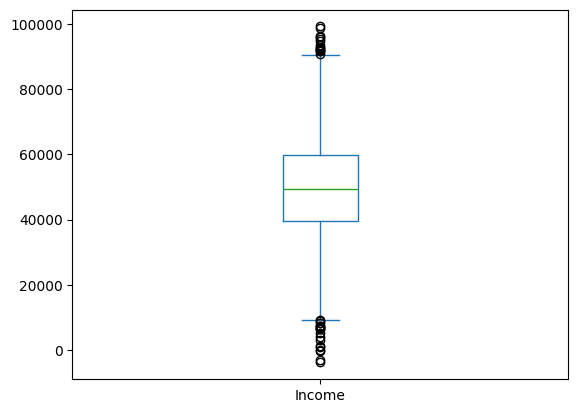

In [101]:
loan_df['Income'].plot(kind='box')

We can see the mostly the data is in range between 40k to 60k. It has many outliers.
In this case we will use median()

In [102]:
loan_df['Income'] = loan_df['Income'].fillna(loan_df['Income'].median())

In [103]:
loan_df.Income.isna().sum()

np.int64(0)

<Axes: >

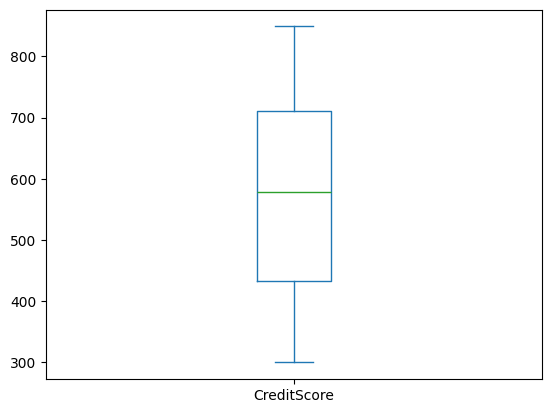

In [104]:
# Now 'credit score'

loan_df['CreditScore'].plot(kind='box')

AS YOU CAN SEE THIS COLUMN DOES NOT HAVE ANY OUTLIERS. SO WE CAN CONFIDENTLY USE MEAN HERE

In [105]:
loan_df['CreditScore'] = loan_df['CreditScore'].fillna(loan_df['CreditScore'].mean())

In [106]:
loan_df.CreditScore.isna().sum()

np.int64(0)

# NOW MOVING ON TO THE CATEGORICAL COLUMN

In [107]:
# the column Education
print(loan_df.Education.value_counts())

Education
Bachelors      1210
Masters        1195
PhD            1192
High School    1177
Name: count, dtype: int64


## OBSERVATION :
* WE CAN USE MODE HERE TO FILL IN THE NULL VALUES AND LATER WE NEED TO CONVERT IT INTO NUMERICAL. WHICH CAN BE DONE BY MAPPING

In [108]:
loan_df['Education'] = loan_df['Education'].fillna(loan_df['Education'].mode()[0])

In [109]:
loan_df['Education'].isna().sum()

np.int64(0)

In [110]:
education_code = {'High School' : 0, 'Bachelors' : 1, 'Masters' : 2, 'PhD' : 3}
loan_df['Education'] = loan_df.Education.map(education_code)

 WE HAVE THREE MORE COLUMNS THAT WE NEED TO TURN INTO NUMERIC

In [111]:
loan_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4972 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              4972 non-null   int64  
 1   Income           4972 non-null   float64
 2   LoanAmount       4972 non-null   float64
 3   CreditScore      4972 non-null   float64
 4   YearsExperience  4972 non-null   int64  
 5   Gender           4972 non-null   object 
 6   Education        4972 non-null   int64  
 7   City             4972 non-null   object 
 8   EmploymentType   4972 non-null   object 
 9   LoanApproved     4972 non-null   int64  
dtypes: float64(3), int64(4), object(3)
memory usage: 427.3+ KB


In [112]:
# first gender it can be mapped easily
gender_code = {'Male' : 0, 'Female' : 1}
loan_df['Gender'] = loan_df.Gender.map(gender_code)

In [113]:
loan_df.Gender.unique()

array([1, 0])

In [114]:
# Now the column Employment type
loan_df.EmploymentType.unique()

array(['Unemployed', 'Self-Employed', 'Salaried'], dtype=object)

# observation :
* We cannot map this because it is not logically right a self-employed person might earn more than a salaried person and vice-versa. So the correct approach here would be One-hot Encoding

In [115]:
loan_df = pd.get_dummies(loan_df, columns = ['EmploymentType'] , drop_first = True)

In [116]:
# converting it into integar
loan_df[['EmploymentType_Self-Employed','EmploymentType_Unemployed']] = loan_df[['EmploymentType_Self-Employed','EmploymentType_Unemployed']].astype(int)

In [117]:
loan_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4972 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Age                           4972 non-null   int64  
 1   Income                        4972 non-null   float64
 2   LoanAmount                    4972 non-null   float64
 3   CreditScore                   4972 non-null   float64
 4   YearsExperience               4972 non-null   int64  
 5   Gender                        4972 non-null   int64  
 6   Education                     4972 non-null   int64  
 7   City                          4972 non-null   object 
 8   LoanApproved                  4972 non-null   int64  
 9   EmploymentType_Self-Employed  4972 non-null   int64  
 10  EmploymentType_Unemployed     4972 non-null   int64  
dtypes: float64(3), int64(7), object(1)
memory usage: 466.1+ KB


In [118]:
loan_df.City.value_counts()

City
Chicago          1289
San Francisco    1255
Houston          1226
New York         1202
Name: count, dtype: int64

* OBSERVATION : WE HAVE ONLY FOR VALUES IN THIS COLUMN SO WE CAN ONE HOT ENCODE HERE

In [120]:
loan_df = pd.get_dummies(loan_df, columns = ['City'], drop_first = True)
loan_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4972 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Age                           4972 non-null   int64  
 1   Income                        4972 non-null   float64
 2   LoanAmount                    4972 non-null   float64
 3   CreditScore                   4972 non-null   float64
 4   YearsExperience               4972 non-null   int64  
 5   Gender                        4972 non-null   int64  
 6   Education                     4972 non-null   int64  
 7   LoanApproved                  4972 non-null   int64  
 8   EmploymentType_Self-Employed  4972 non-null   int64  
 9   EmploymentType_Unemployed     4972 non-null   int64  
 10  City_Houston                  4972 non-null   bool   
 11  City_New York                 4972 non-null   bool   
 12  City_San Francisco            4972 non-null   bool   
dtypes: bool(

In [121]:
loan_df[['City_Houston','City_New York','City_San Francisco']] = loan_df[['City_Houston','City_New York','City_San Francisco']].astype(int)

In [122]:
loan_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4972 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Age                           4972 non-null   int64  
 1   Income                        4972 non-null   float64
 2   LoanAmount                    4972 non-null   float64
 3   CreditScore                   4972 non-null   float64
 4   YearsExperience               4972 non-null   int64  
 5   Gender                        4972 non-null   int64  
 6   Education                     4972 non-null   int64  
 7   LoanApproved                  4972 non-null   int64  
 8   EmploymentType_Self-Employed  4972 non-null   int64  
 9   EmploymentType_Unemployed     4972 non-null   int64  
 10  City_Houston                  4972 non-null   int64  
 11  City_New York                 4972 non-null   int64  
 12  City_San Francisco            4972 non-null   int64  
dtypes: float

# VISULIZATION

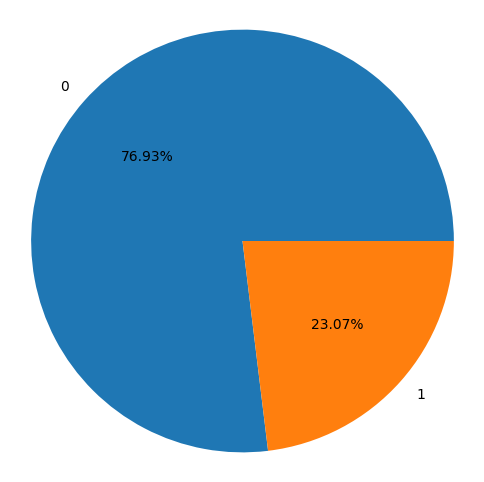

In [124]:
counts = loan_df['LoanApproved'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(counts.values,
        labels=counts.index,
        autopct='%1.2f%%')

plt.axis('equal')
plt.show()

In [125]:
loan_df.columns

Index(['Age', 'Income', 'LoanAmount', 'CreditScore', 'YearsExperience',
       'Gender', 'Education', 'LoanApproved', 'EmploymentType_Self-Employed',
       'EmploymentType_Unemployed', 'City_Houston', 'City_New York',
       'City_San Francisco'],
      dtype='object')

<Axes: xlabel='LoanApproved', ylabel='Income'>

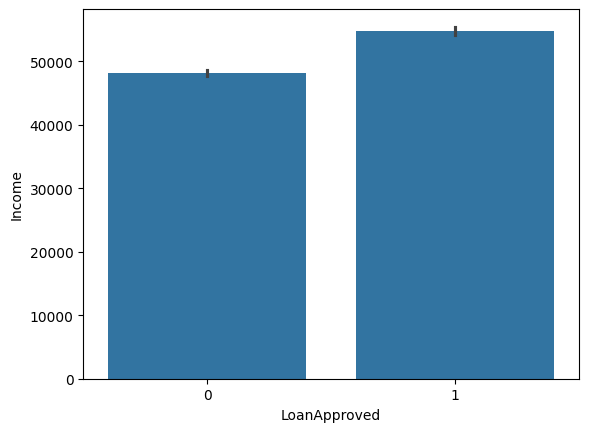

In [129]:
sns.barplot(x='LoanApproved', y='Income', data=loan_df)

<Axes: xlabel='Education', ylabel='count'>

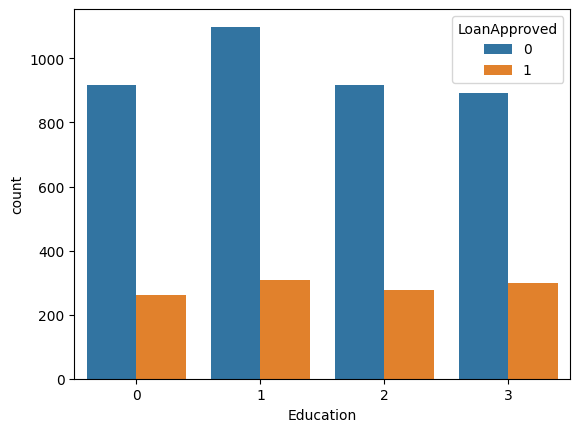

In [130]:
sns.countplot(x='Education', hue='LoanApproved', data=loan_df)

# TRAINING THE MODEL

In [131]:
X = loan_df.drop('LoanApproved', axis = 1)
Y = loan_df['LoanApproved']

print(X.shape)
print(Y.shape)

(4972, 12)
(4972,)


In [132]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train , y_test = train_test_split(X,Y, test_size=0.25,random_state=42)

In [133]:
# CREATING A FUNCTION TO TEST DIFFERENT MODELS
from sklearn.metrics import confusion_matrix,accuracy_score

def train_model(model, X_train, Y_train, X_test, Y_test):
    model.fit(X_train, Y_train)
    predictions = model.predict(X_test)
    cm = confusion_matrix(Y_test,predictions)
    plt.title('Confusion Matrix')
    sns.heatmap(cm,annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    
    return {
        "model": model.__class__.__name__,

        "accuracy": accuracy_score(Y_test, predictions),
        
        'Cm' : confusion_matrix(Y_test,predictions)
    }

In [134]:
# finding the suitable depth for a tree based model
from sklearn.tree import DecisionTreeClassifier

def depth(md):
    model = DecisionTreeClassifier(max_depth = md, random_state=42)
    model.fit(x_train,y_train)
    train_error = 1 - model.score(x_train,y_train)
    y_pred = model.predict(x_test)
    accuracy = accuracy_score(y_test,y_pred)

    return{
        'Max_depth' : md,
        'Training-Error' : train_error,
        'Accuracy' : accuracy
    }

In [135]:
error = pd.DataFrame([
    depth(md)
    for md in range(1,21)
])

In [136]:
error

,Max_depth,Training-Error,Accuracy
0,1,0.228748,0.763475
1,2,0.100027,0.888978
2,3,0.032180,0.976669
3,4,0.031108,0.974256
4,5,0.029767,0.974256
5,6,0.028158,0.969429
6,7,0.025476,0.962188
7,8,0.021990,0.960579
8,9,0.020113,0.958970
9,10,0.016358,0.954948


from the above dataframe we can see max depth of 7 will be perfect

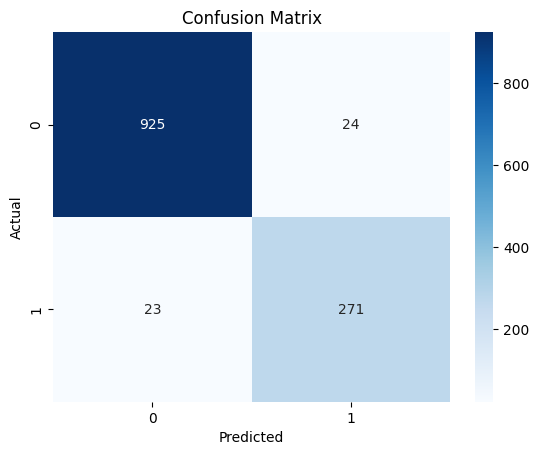

{'model': 'DecisionTreeClassifier',
 'accuracy': 0.9621882542236525,
 'Cm': array([[925,  24],
        [ 23, 271]])}

In [137]:
model = DecisionTreeClassifier(max_depth=7, random_state=42)
train_model(model, x_train, y_train, x_test, y_test)